# Compare Spike Train Similarity for Visually Evoked vs Electrically Evoked Responses

In [171]:
%reload_ext autoreload
%autoreload 2

# Imports
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import pickle
import src.utils.preprocess as preprocess
# import src.utils.sigmoid as sigmoid
from scipy.io import savemat, loadmat
from scipy.signal import convolve2d
from scipy.stats import zscore, norm, chi2, chisquare, ncx2, ttest_ind, mannwhitneyu
import re
import visionloader as vl
import sta_utils as su
from scipy.spatial import ConvexHull
import src.utils.cellmap as cellmap
import src.utils.encoding_decoding_simulation_pooled as edsp
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Ellipse
from PIL import Image
import multiprocessing
from multiprocessing import Pool
import warnings
from matplotlib.lines import Line2D
import eilib as eil

import sys
sys.path.append('/Volumes/Lab/Users/ajphillips/greedy/src/')
import sigmoid

from quantities import ms, s, Hz
from elephant.spike_train_generation import homogeneous_poisson_process
from elephant.spike_train_dissimilarity import victor_purpura_distance
from neo.core import SpikeTrain

Paths

In [286]:
piece = '2024-10-02-2'
label = "_2"
wnoise = 'data002'
cell_types = ['ON parasol', 'OFF parasol']
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
spike_path = os.path.join(analysis_base, f"spikes{label}")
wnoise_path = os.path.join(analysis_base, wnoise)

frame_no = 1

# Load response indices
spike_trains = np.load(f"{analysis_base}/dictionary/spike_trains{label}.npz", allow_pickle=True)
response_indices = spike_trains['response_indices']
vstim_trial = (response_indices[frame_no] - 30) // 100

In [287]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)

In [288]:
vcd = vl.load_vision_data(wnoise_path,wnoise,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True,
                        include_noise=True)

coords = vcd.get_electrode_map()

In [289]:
def get_smart_stimuli(cell_ids_for_stimulus, selective_stimuli, plot):
    # selective_stimuli row is [electrode, cell, amp, pure]
    # sef row is [time, electrode, amp]

    # Find the selective stimuli that match the cell IDs
    matching_stimuli = []
    for cell_id in cell_ids_for_stimulus:
        matching_stimuli.extend([stimulus for stimulus in selective_stimuli if stimulus[1] == cell_id])
    matching_stimuli = np.array(matching_stimuli)

    # Plot the electrodes
    if plot:
        fig, ax = plt.subplots()
        ax.plot(coords[:,0], coords[:,1], 'k.')

        # Plot the selective electrodes corresponding to each cell_id in different colors
        colors = cm.rainbow(np.linspace(0, 1, len(cell_ids_for_stimulus)))
        for i, cell_id in enumerate(cell_ids_for_stimulus):
            cell_id_elecs = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]][:,0].astype(int)
            ax.plot(coords[cell_id_elecs-1,0], coords[cell_id_elecs-1,1], 'o', color=colors[i])

    # Choose the selective electrode closest to the soma center for each cell
    selected_electrodes = []
    for i, cell_id in enumerate(cell_ids_for_stimulus):
        cell_ei = vcd.get_ei_for_cell(cell_id).ei
        ei = np.amin(cell_ei,axis=1)

        # Find soma position
        thresh = -2
        inds = np.argwhere(ei < thresh).flatten()
        soma_inds = []
        soma_ei_vals = []
        for ind in inds:
            if eil.axonorsomaRatio(cell_ei[ind,:]) == 'soma':
                soma_inds.append(ind)
                soma_ei_vals.append(np.min(cell_ei[ind,:]))
        soma_pos = eil.getSomaLocThr(np.array(soma_inds), np.array(soma_ei_vals), coords)

        # Find the selective electrode closest to the soma center
        cell_id_matching_stimuli = matching_stimuli[np.where(matching_stimuli[:,1] == cell_id)[0]]
        index = np.argmin(np.linalg.norm(coords[cell_id_matching_stimuli[:,0].astype(int)-1] - soma_pos, axis=1))
        selected_electrode = cell_id_matching_stimuli[index][0].astype(int)
        selected_electrodes.append(selected_electrode)
        # Designate these electrodes on the plot
        if plot:
            ax.plot(coords[selected_electrode-1,0], coords[selected_electrode-1,1], 'X', color=colors[i], markersize=15)

    if plot:
        ax.set_aspect('equal')
        plt.show()

    return np.array(selected_electrodes)

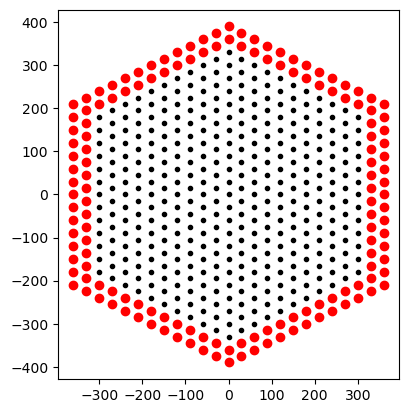

In [290]:
# Find all electrodes which have less than 5 neighbors within 40 um
hull_electrodes = []
for i in range(len(coords)):
    dists = np.linalg.norm(coords - coords[i], axis=1)
    if len(np.where(dists < 40)[0]) < 6:
        hull_electrodes.append(i+1)
hull_electrodes = np.array(hull_electrodes)

# Find double hull electrodes which are all electrodes within 40 um of the hull electrodes
double_hull_electrodes = []
for i in hull_electrodes:
    dists = np.linalg.norm(coords - coords[i-1], axis=1)
    double_hull_electrodes.extend(np.where(dists < 40)[0]+1)
double_hull_electrodes = np.unique(double_hull_electrodes)

# Plot the electrodes and the hull_electrodes in a different color
fig, ax = plt.subplots()
ax.plot(coords[:,0], coords[:,1], 'k.')
ax.plot(coords[double_hull_electrodes-1,0], coords[double_hull_electrodes-1,1], 'o', color='r')
ax.set_aspect('equal')
plt.show()


Transform to SpikeTrain objects

In [291]:
vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
for i in range(vstim_responses.shape[0]):
    if len(vstim_responses[i]) == 0:
        for j in range(len(selective_cells_of_interest)):
            vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1300.0*ms)
    else:
        for j in range(len(selective_cells_of_interest)):
            vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1300.0*ms)

estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
for i in range(estim_espont_responses.shape[0]):
    if len(estim_espont_responses[i]) == 0:
        for j in range(len(selective_cells_of_interest)):
            estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1300.0*ms)
    else:
        for j in range(len(selective_cells_of_interest)):
            estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1300.0*ms)

In [292]:
print(vstim_responses.shape)
print(estim_espont_responses.shape)

(15, 37)
(15, 37)


Compute Victor-Purpura spike train distances

In [ ]:
q = 1. / (5. * ms) # q=0 means no cost for any shift of spikes, q=np.inf means infinite cost for any spike shift and hence exclusion of spike shifts

vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
for i in tqdm(range(vstim_spike_trains.shape[1])):

    spike_train_list = []
    for j in range(vstim_spike_trains.shape[0]):
        spike_train_list.append(vstim_spike_trains[j,i])

    vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
for i in tqdm(range(estim_espont_spike_trains.shape[1])):

    spike_train_list = []
    spike_train_list.append(vstim_spike_trains[vstim_trial,i])
    for j in range(estim_espont_spike_trains.shape[0]):
        spike_train_list.append(estim_espont_spike_trains[j,i])

    estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

In [ ]:
print(vstim_vp_distance.shape)
print(estim_espont_vp_distance.shape)

In [ ]:
normalized_scores = []
alph = 0.05
cells_to_exclude = []
cells_failed = []

for c in range(len(selective_cells_of_interest)):
    # Plot the visually evoked spike train and all of the electrically evoked spike trains on the same plot for cell c
    plt.figure()

    # Create a spike raster plot
    cell_responses = []
    for i in range(vstim_responses.shape[0]):
        cell_responses.append(vstim_responses[i,c])
    plt.eventplot(cell_responses, linelengths=0.5, colors=['red' if i == vstim_trial else 'k' for i in range(vstim_responses.shape[0])])

    # Set the y-axis ticks and labels
    plt.yticks(range(vstim_responses.shape[0]), [f'Visual {i}' for i in range(vstim_responses.shape[0])])
    plt.ylabel('Stimulus')

    # Set the x-axis label
    plt.xlabel('Time (ms)')
    plt.xlim(0, 500)

    # Set the plot title
    plt.title(f"Cell {selective_cells_of_interest[c]}")

    # Show the plot
    plt.show()


    # Plot the visually evoked spike train and all of the electrically evoked spike trains on the same plot for cell c
    plt.figure()

    # Create a spike raster plot
    cell_responses = []
    cell_responses.append(vstim_responses[vstim_trial,c])
    for i in range(estim_espont_responses.shape[0]):
        cell_responses.append(estim_espont_responses[i,c])
    plt.eventplot(cell_responses, linelengths=0.5, colors=['red'] + ['blue']*estim_espont_responses.shape[0])

    # Set the y-axis ticks and labels
    plt.yticks(range(estim_espont_responses.shape[0]+1), [f'Visual {vstim_trial}'] + [f'Estim Espont {i}' for i in range(estim_espont_responses.shape[0])])
    plt.ylabel('Stimulus')

    # Set the x-axis label
    plt.xlabel('Time (ms)')
    plt.xlim(0, 500)

    # Set the plot title
    plt.title(f"Cell {selective_cells_of_interest[c]}")

    # Show the plot
    plt.show()


    # vstim_vp = vstim_vp_distance[c][np.triu_indices(vstim_vp_distance.shape[1],1)].flatten()
    vstim_vp = vstim_vp_distance[c,0,1:]
    estim_espont_vp = estim_espont_vp_distance[c,0,1:]

    # if np.all(vstim_vp == 0):
    #     warnings.warn(f"Cell {selective_cells_of_interest[c]} has all 0 Victor-Purpura distances for visual trials")
    #     normalized_scores.append(None)
    # else:
    plt.figure()

    # plot Victor-Purpura pairwise distance for visual trials
    plt.hist(vstim_vp, bins=np.arange(100), density=True, color='k', alpha=0.5)
    x = np.arange(0,100,0.01)

    # plot average Victor-Purpura pairwise distance for target visual trial
    vstim_vp_target = vstim_vp_distance[c,0,1:]
    plt.axvline(np.mean(vstim_vp_target), color='k', linestyle='--')

    # # Normal distribution fitting
    # plt.plot(x, norm.pdf(x, np.mean(vstim_vp), np.std(vstim_vp)), color='r')

    # # plot 2 std dev lines
    # plt.axvline(np.mean(vstim_vp) - 2*np.std(vstim_vp), color='r', linestyle='--')
    # plt.axvline(np.mean(vstim_vp) + 2*np.std(vstim_vp), color='r', linestyle='--')

    # normalized_scores.append((np.mean(estim_espont_vp) - np.mean(vstim_vp)) / np.std(vstim_vp)) # z-score


    # Chi-square distribution fitting
    # fit_params = chi2.fit(vstim_vp, floc=0, fscale=1)
    # df_fit, loc_fit, scale_fit = fit_params
    # print("Degrees of Freedom (df):", df_fit)
    # print("Location (loc):", loc_fit)
    # print("Scale (scale):", scale_fit)

    # # plot the chi-square fit
    # y = chi2.pdf(x, df_fit, loc_fit, scale_fit)
    # plt.plot(x, y, 'pink', label='Chi-square Fit')

    # # Plot the chi-square critical value for significance level 0.05
    # chi2_critical = chi2.ppf(1-alph, df_fit, loc_fit, scale_fit)
    # plt.axvline(chi2_critical, color='pink', linestyle='--', label='Chi-square Critical Value')

    # normalized_scores.append(chi2.cdf(np.mean(estim_espont_vp), df_fit, loc_fit, scale_fit)) # p-value

    # plot Victor-Purpura distance for selected visual trial to estim espont trials
    plt.hist(estim_espont_vp, bins=np.arange(25), density=True, color='blue', alpha=0.5)

    # plot average
    plt.axvline(np.mean(estim_espont_vp), color='blue', linestyle='--')

    plt.title(f"Visual Stimulus {frame_no} Cell {selective_cells_of_interest[c]}")
    plt.xlabel("Victor-Purpura Distance")
    plt.ylabel("Density")
    plt.xlim(0,25)
    plt.ylim(0,1)
    plt.show()

    # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
    # print(ttest)
    # normalized_scores.append(ttest[1]) # p-value

    mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
    print(mannwhitney)
    normalized_scores.append(mannwhitney[1]) # p-value

    # Plot the receptive field of the selected cell
    fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(25,10))

    STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX
    cell_types = ['ON parasol', 'OFF parasol']

    for ax, cell_type in zip(axs, cell_types):
        for c1 in selective_cells_of_interest:
            if c1 not in vcd.get_all_cells_similar_to_type(cell_type):
                continue
            center_x = STIXEL * vcd.get_stafit_for_cell(c1).center_x
            center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c1).center_y)
            std_x = STIXEL * vcd.get_stafit_for_cell(c1).std_x
            std_y = STIXEL * vcd.get_stafit_for_cell(c1).std_y
            rot = vcd.get_stafit_for_cell(c1).rot

            rf1 = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=-rot*180/np.pi, fill=True)

            if c1 == selective_cells_of_interest[c]:
                rf1.set_facecolor('red')
            else:
                rf1.set_facecolor('green')            
            rf1.set_edgecolor('black')
            ax.add_patch(rf1)

        ax.set_xlim(0, 640-1)
        ax.set_ylim(0, 320-1)
        ax.set_aspect('equal')
        ax.set_title(cell_type)
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)

    plt.show()

    # Plot the EI of the selected cell
    for cell_id in [selective_cells_of_interest[c]]:

        # Extract EI for desired cell
        cell_ei = vcd.get_ei_for_cell(cell_id).ei

        # Find negative peak for each recording electrode
        ei = np.amin(cell_ei,axis=1)
        thresh = -1
        good_inds = np.argwhere(ei < thresh).flatten()
        channel_noise = vcd.channel_noise

        # Assign compartments
        soma_inds = []
        axon_inds = []
        mixed_inds = []
        dendrite_inds = []
        for elec in good_inds:
            if eil.axonorsomaRatio(cell_ei[elec,:]) == 'soma':
                soma_inds.append(elec)
            elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'axon':
                axon_inds.append(elec)
            elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'dendrite':
                dendrite_inds.append(elec)
            elif eil.axonorsomaRatio(cell_ei[elec,:]) == 'mixed':
                mixed_inds.append(elec)

        fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(15,15))

        # Plot electrodes
        coords = vcd.get_electrode_map()
        ax.scatter(coords[:,0], coords[:,1], facecolors='none', edgecolors='k', s=20)

        # Plot EI
        ei_size_factor = -100
        ax.scatter(coords[soma_inds,0], coords[soma_inds,1], facecolors=eil.corrColDict['soma'], 
                edgecolors='none', s=ei[soma_inds]*ei_size_factor, alpha=0.8)
        ax.scatter(coords[axon_inds,0], coords[axon_inds,1], facecolors=eil.corrColDict['axon'], 
                edgecolors='none', s=ei[axon_inds]*ei_size_factor, alpha=0.8)
        ax.scatter(coords[mixed_inds,0], coords[mixed_inds,1], facecolors=eil.corrColDict['mixed'], 
                edgecolors='none', s=ei[mixed_inds]*ei_size_factor, alpha=0.8)
        ax.scatter(coords[dendrite_inds,0], coords[dendrite_inds,1], facecolors=eil.corrColDict['dendrite'], 
                edgecolors='none', s=ei[dendrite_inds]*ei_size_factor, alpha=0.8)

        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
        ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
        # ax.set_xlim([min(coords[good_inds,0])-100, max(coords[good_inds,0])+100])
        # ax.set_ylim([min(coords[good_inds,1])-100, max(coords[good_inds,1])+100])
        ax.axes.set_aspect('equal')


        legend_elements = [Line2D([0], [0], marker='o', color='w', label='Soma',
                        markerfacecolor=eil.corrColDict['soma'], markersize=15),
                        Line2D([0], [0], marker='o', color='w', label='Axon',
                        markerfacecolor=eil.corrColDict['axon'], markersize=15),
                        Line2D([0], [0], marker='o', color='w', label='Mixed',
                        markerfacecolor=eil.corrColDict['mixed'], markersize=15),
                        Line2D([0], [0], marker='o', color='w', label='Dendrite',
                        markerfacecolor=eil.corrColDict['dendrite'], markersize=15)]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=20)

        # Identify from selective_stimuli which electrodes are selective for cell_id, and get the corresponding amp
        selective_subset = selective_stimuli[selective_stimuli[:,1] == cell_id]
        selective_electrodes = selective_subset[:,0].astype(int)
        selective_amps = selective_subset[:,2]

        # Label electrodes
        for z,elec in enumerate(selective_electrodes):
            num = f"{elec}:{selective_amps[z]:.2f}"
            plt.annotate(num, (coords[elec-1,0],coords[elec-1,1]), textcoords='offset points', xytext=(0,12), ha='center', fontsize=10)

        plt.show()

    smart_stimuli = get_smart_stimuli([selective_cells_of_interest[c]], selective_stimuli, plot=False)
    print(smart_stimuli)

    if smart_stimuli[0] in double_hull_electrodes and mannwhitney[1] < alph:
        print(f"Cell {selective_cells_of_interest[c]} is on the edge of the array and has a p-value less than {alph}")
        cells_to_exclude.append(selective_cells_of_interest[c])
    elif mannwhitney[1] < alph:
        print(f"Cell {selective_cells_of_interest[c]} has a p-value less than {alph}")
        cells_failed.append(selective_cells_of_interest[c])

normalized_scores = np.array(normalized_scores)

In [ ]:
# Plot the cells again with the cells to exclude highlighted
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(25,10))

STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX
cell_types = ['ON parasol', 'OFF parasol']

for ax, cell_type in zip(axs, cell_types):
    for c1 in selective_cells_of_interest:
        if c1 not in vcd.get_all_cells_similar_to_type(cell_type):
            continue
        center_x = STIXEL * vcd.get_stafit_for_cell(c1).center_x
        center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c1).center_y)
        std_x = STIXEL * vcd.get_stafit_for_cell(c1).std_x
        std_y = STIXEL * vcd.get_stafit_for_cell(c1).std_y
        rot = vcd.get_stafit_for_cell(c1).rot

        rf1 = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=-rot*180/np.pi, fill=True)

        if c1 in cells_to_exclude:
            rf1.set_facecolor('gray')
        elif c1 in cells_failed:
            rf1.set_facecolor('red')
        else:
            rf1.set_facecolor('green')        
        rf1.set_edgecolor('black')
        ax.add_patch(rf1)

    ax.set_xlim(0, 640-1)
    ax.set_ylim(0, 320-1)
    ax.set_aspect('equal')
    ax.set_title(cell_type)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.show()

In [ ]:
plt.figure()
plt.hist(normalized_scores, bins=np.arange(0,1.05,0.05), density=False, color='k', alpha=0.5)
plt.axvline(alph, color='r', linestyle='--')
plt.xlabel("p-value")
plt.ylabel("number of cells")
plt.title(f"p-values of Mann-Whitney U test on Victor-Purpura distance\nfor visually evoked versus reproduced spike trains\n\nFrame {frame_no}, q={q}")
plt.show()

In [ ]:
# Get indices of cells to include
cells_to_include = np.setdiff1d(selective_cells_of_interest, cells_to_exclude)
cells_to_include_indices = np.array([np.where(selective_cells_of_interest == cell)[0][0] for cell in cells_to_include])

plt.figure()
plt.hist(normalized_scores[cells_to_include_indices], bins=np.arange(0,1.05,0.05), density=False, color='k', alpha=0.5)
plt.axvline(alph, color='r', linestyle='--')
plt.xlabel("p-value")
plt.ylabel("number of cells")
plt.title(f"p-values of Mann-Whitney U test on Victor-Purpura distance\nfor visually evoked versus reproduced spike trains\n\nFrame {frame_no}, q={q}")
plt.show()

In [ ]:
# selective_cells_of_interest = selective_cells_of_interest[cells_to_include_indices]
# vstim_responses = vstim_responses[:,cells_to_include_indices]
# estim_espont_responses = estim_espont_responses[:,cells_to_include_indices]
# vstim_vp_distance = vstim_vp_distance[cells_to_include_indices]
# estim_espont_vp_distance = estim_espont_vp_distance[cells_to_include_indices]

In [ ]:
print(selective_cells_of_interest.shape)
print(vstim_responses.shape)
print(estim_espont_responses.shape)
print(vstim_vp_distance.shape)
print(estim_espont_vp_distance.shape)

In [ ]:
alph = 0.05

if True:
    for i in range(vstim_responses.shape[0]):

        plt.figure()

        # Create a spike raster plot
        plt.eventplot(vstim_responses[i], linelengths=0.5, colors='black')

        # Set the y-axis ticks and labels
        plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
        plt.ylabel('Cell ID')

        # Set the x-axis label
        plt.xlabel('Time (ms)')

        # Set the plot title
        plt.title(f"Visual {i}")

        # Restrict the x axis
        plt.xlim(0, 500)

        # Close the plot
        plt.show()

    for i in range(estim_espont_responses.shape[0]):

        plt.figure()

        # Make two lineoffsets vectors offset by a constant value
        lineoffsets1 = np.arange(len(selective_cells_of_interest))
        lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

        # Create a spike raster plot
        plt.eventplot(vstim_responses[vstim_trial], linelengths=0.5, lineoffsets=lineoffsets1, colors='black')
        plt.eventplot(estim_espont_responses[i], linelengths=0.5, lineoffsets=lineoffsets2, colors='red')

        # Set the y-axis ticks and labels
        plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
        plt.ylabel('Cell ID')

        # Set the x-axis label
        plt.xlabel('Time (ms)')

        # Set the plot title
        plt.title(f"Electrical {i}")

        # Restrict the x axis
        plt.xlim(0, 500)

        # Close the plot
        plt.show()

# Multi-neuron Victor-Purpura distance with k=2
vstim_vp = np.sum(vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]], axis=0)
estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)

print(vstim_vp)
print(estim_espont_vp)

plt.figure()

# plot multi-neuron Victor-Purpura distance for visual trials
max_dist = np.max(np.concatenate((vstim_vp,estim_espont_vp)))
x = np.arange(0,max_dist+10,10)
plt.hist(vstim_vp, bins=x, density=True, color='k', alpha=0.5)

# plot average
plt.axvline(np.mean(vstim_vp), color='k', linestyle='--')

# plot multi-neuron Victor-Purpura distance for selected visual trial to estim espont trials
plt.hist(estim_espont_vp, bins=x, density=True, color='blue', alpha=0.5)

# plot average
plt.axvline(np.mean(estim_espont_vp), color='blue', linestyle='--')

plt.title(f"Visual Stimulus {frame_no}, q={q}")
plt.xlabel("Victor-Purpura Distance")
plt.ylabel("Density")
plt.xlim(0,max_dist)
plt.ylim(0,1)
plt.show()

# ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
# print(ttest)

mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
print(mannwhitney)


In [ ]:
# frame_nos = np.arange(100)
# q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (10. * ms), 1. / (100. * ms), 0. / (1. * ms)]

# mannwhitney_p_values = np.empty((len(frame_nos), len(q_list), len(selective_cells_of_interest)))

# for frame_no in tqdm(frame_nos):

#     vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
#     estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

#     vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
#     for i in range(vstim_responses.shape[0]):
#         if len(vstim_responses[i]) == 0:
#             for j in range(len(selective_cells_of_interest)):
#                 vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=0.0*ms, t_stop=805.0*ms)
#         else:
#             for j in range(len(selective_cells_of_interest)):
#                 vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
#     for i in range(estim_espont_responses.shape[0]):
#         if len(estim_espont_responses[i]) == 0:
#             for j in range(len(selective_cells_of_interest)):
#                 estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=0.0*ms, t_stop=805.0*ms)
#         else:
#             for j in range(len(selective_cells_of_interest)):
#                 estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     cmap = plt.get_cmap('rainbow')
#     colors = cmap(np.linspace(0, 1, len(q_list)))

#     for k,q in enumerate(q_list):

#         vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
#         for i in range(vstim_spike_trains.shape[1]):

#             spike_train_list = []
#             for j in range(vstim_spike_trains.shape[0]):
#                 spike_train_list.append(vstim_spike_trains[j,i])

#             vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

#         estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
#         for i in range(estim_espont_spike_trains.shape[1]):

#             spike_train_list = []
#             spike_train_list.append(vstim_spike_trains[vstim_trial,i])
#             for j in range(estim_espont_spike_trains.shape[0]):
#                 spike_train_list.append(estim_espont_spike_trains[j,i])

#             estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


#         for c in range(len(selective_cells_of_interest)):
#             vstim_vp = vstim_vp_distance[c,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
#             estim_espont_vp = estim_espont_vp_distance[c,0,1:]

#             # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
#             # ttest_p_values[frame_no-5,k,c] = ttest[1]

#             mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
#             mannwhitney_p_values[frame_no,k,c] = mannwhitney[1]

In [293]:
frame_nos = np.arange(1,99)
q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (5. * ms), 1. / (10. * ms), 1. / (50. * ms), 1. / (100. * ms), 0. / (1. * ms)]

mannwhitney_p_values = np.empty((len(frame_nos), len(q_list), len(selective_cells_of_interest)))

def loop_fun(frame_no):
    
    vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
    estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

    vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
    for i in range(vstim_responses.shape[0]):
        if len(vstim_responses[i]) == 0:
            for j in range(len(selective_cells_of_interest)):
                vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1000.0*ms)
        else:
            for j in range(len(selective_cells_of_interest)):
                vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1000.0*ms)

    estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
    for i in range(estim_espont_responses.shape[0]):
        if len(estim_espont_responses[i]) == 0:
            for j in range(len(selective_cells_of_interest)):
                estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1000.0*ms)
        else:
            for j in range(len(selective_cells_of_interest)):
                estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1000.0*ms)

    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, len(q_list)))

    intermediate_mannwhitney_p_values = np.empty((len(q_list), len(selective_cells_of_interest)))

    for k,q in enumerate(q_list):

        vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
        for i in range(vstim_spike_trains.shape[1]):

            spike_train_list = []
            for j in range(vstim_spike_trains.shape[0]):
                spike_train_list.append(vstim_spike_trains[j,i])

            vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

        estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
        for i in range(estim_espont_spike_trains.shape[1]):

            spike_train_list = []
            spike_train_list.append(vstim_spike_trains[vstim_trial,i])
            for j in range(estim_espont_spike_trains.shape[0]):
                spike_train_list.append(estim_espont_spike_trains[j,i])

            estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


        for c in range(len(selective_cells_of_interest)):
            vstim_vp = vstim_vp_distance[c,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
            estim_espont_vp = estim_espont_vp_distance[c,0,1:]

            # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
            # ttest_p_values[frame_no-5,k,c] = ttest[1]

            mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
            intermediate_mannwhitney_p_values[k,c] = mannwhitney[1]

    return intermediate_mannwhitney_p_values

with Pool(36) as p:
    results = list(tqdm(p.imap(loop_fun, frame_nos), total=len(frame_nos)))

    for i in range(len(results)):
        mannwhitney_p_values[i,:,:] = results[i]

100%|██████████| 98/98 [03:20<00:00,  2.05s/it] 


In [294]:
print(mannwhitney_p_values.shape)

(98, 7, 37)


In [295]:
alph = 0.05
cells_to_exclude = []
cells_failed = []

for c in range(len(selective_cells_of_interest)):
    p_value = np.mean(mannwhitney_p_values[:,2,c]) # 5 ms temporal resolution

    smart_stimuli = get_smart_stimuli([selective_cells_of_interest[c]], selective_stimuli, plot=False)

    if smart_stimuli[0] in double_hull_electrodes and p_value < alph:
        print(f"Cell {selective_cells_of_interest[c]} is on the edge of the array and has a p-value less than {alph}")
        cells_to_exclude.append(selective_cells_of_interest[c])
    elif p_value < alph:
        print(f"Cell {selective_cells_of_interest[c]} has a p-value less than {alph}")
        cells_failed.append(selective_cells_of_interest[c])

In [296]:
print(f"{len(selective_cells_of_interest) - len(cells_to_exclude) - len(cells_failed)}/{len(selective_cells_of_interest) - len(cells_to_exclude)}/{len(selective_cells_of_interest)}")

37/37/37


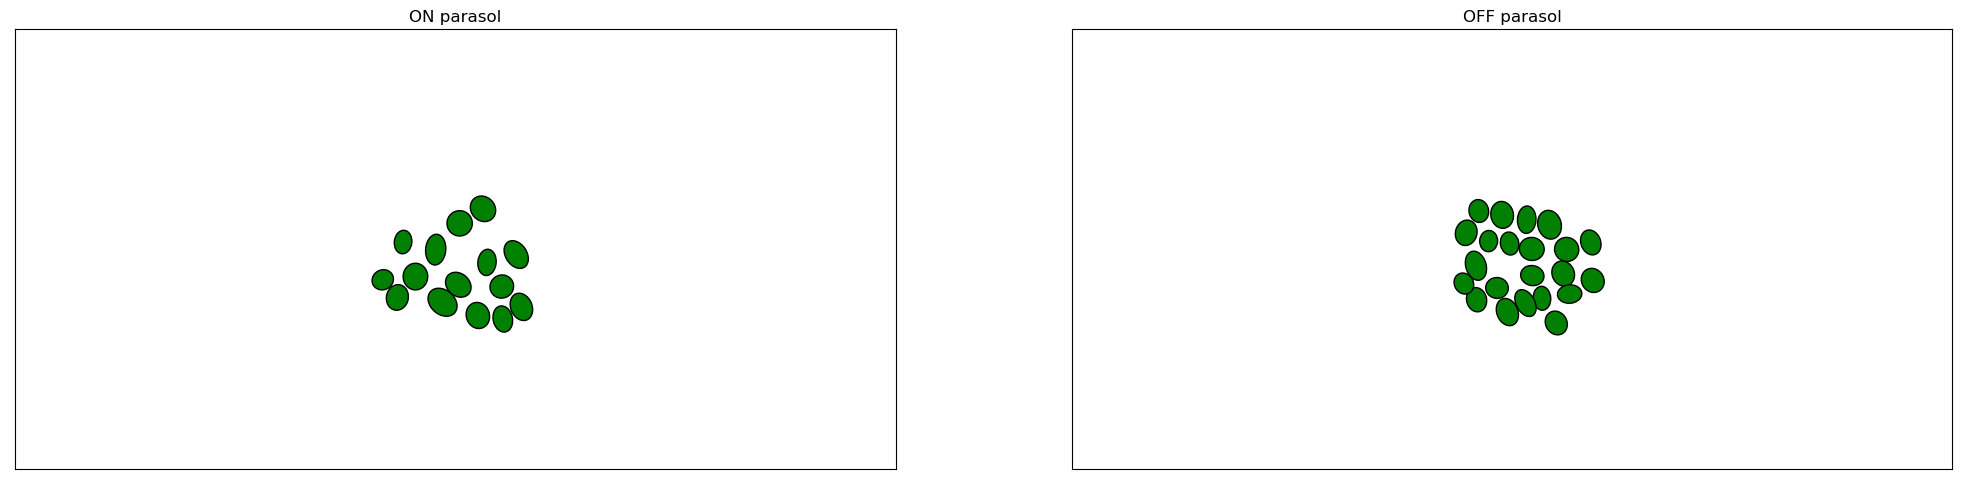

In [297]:
# Plot the cells again with the cells to exclude highlighted
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(25,10))

STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX
cell_types = ['ON parasol', 'OFF parasol']

for ax, cell_type in zip(axs, cell_types):
    for c1 in selective_cells_of_interest:
        if c1 not in vcd.get_all_cells_similar_to_type(cell_type):
            continue
        center_x = STIXEL * vcd.get_stafit_for_cell(c1).center_x
        center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c1).center_y)
        std_x = STIXEL * vcd.get_stafit_for_cell(c1).std_x
        std_y = STIXEL * vcd.get_stafit_for_cell(c1).std_y
        rot = vcd.get_stafit_for_cell(c1).rot

        rf1 = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=-rot*180/np.pi, fill=True)

        if c1 in cells_to_exclude:
            rf1.set_facecolor('gray')
        elif c1 in cells_failed:
            rf1.set_facecolor('red')
        else:
            rf1.set_facecolor('green')        
        rf1.set_edgecolor('black')
        ax.add_patch(rf1)

    ax.set_xlim(0, 640-1)
    ax.set_ylim(0, 320-1)
    ax.set_aspect('equal')
    ax.set_title(cell_type)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)

plt.show()

In [298]:
# Make boolean mask for cells to include
cells_to_include_mask = np.array([False if c in cells_to_exclude else True for c in selective_cells_of_interest])
print(f"Using {np.sum(cells_to_include_mask)} cells")

Using 37 cells


In [299]:
# for k,q in enumerate(q_list):
#     plt.figure(figsize=(15,5))

#     boxplot_data = []
#     for c in range(len(selective_cells_of_interest)):
#         temp = mannwhitney_p_values[:,k,c]
#         # temp = temp[~np.isnan(temp)] # ignore nan (t-test could not be calculated for VP distances for some frames)
#         boxplot_data.append(temp)

#     plt.boxplot(boxplot_data, labels=np.arange(len(selective_cells_of_interest)))

#     plt.axhline(alph, color='k', linestyle='--')
#     plt.xlabel("Cell Index")
#     plt.ylabel("p-value")
#     plt.ylim(0,1)
#     plt.title(f"Mann-Whitney U test p-values for Victor-Purpura distance\nfor visually evoked versus reproduced spike trains\n\nq={q}")
#     plt.show()

In [300]:
# frame_nos = np.arange(100)

# for frame_no in frame_nos:

#     vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
#     estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

#     # vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
#     # for i in range(vstim_responses.shape[0]):
#     #     for j in range(vstim_responses.shape[1]):
#     #         vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     # estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
#     # for i in range(estim_espont_responses.shape[0]):
#     #     for j in range(estim_espont_responses.shape[1]):
#     #         estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
#     for i in range(vstim_responses.shape[0]):
#         if len(vstim_responses[i]) == 0:
#             for j in range(len(selective_cells_of_interest)):
#                 vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=0.0*ms, t_stop=805.0*ms)
#         else:
#             for j in range(len(selective_cells_of_interest)):
#                 vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
#     for i in range(estim_espont_responses.shape[0]):
#         if len(estim_espont_responses[i]) == 0:
#             for j in range(len(selective_cells_of_interest)):
#                 estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=0.0*ms, t_stop=805.0*ms)
#         else:
#             for j in range(len(selective_cells_of_interest)):
#                 estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     plt.figure()

#     q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (10. * ms), 1. / (100. * ms), 0. / (1. * ms)]
#     cmap = plt.get_cmap('rainbow')
#     colors = cmap(np.linspace(0, 1, len(q_list)))
#     max_dist_overall = -1

#     for k,q in enumerate(q_list):

#         vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
#         for i in tqdm(range(vstim_spike_trains.shape[1])):

#             spike_train_list = []
#             for j in range(vstim_spike_trains.shape[0]):
#                 spike_train_list.append(vstim_spike_trains[j,i])

#             vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

#         estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
#         for i in tqdm(range(estim_espont_spike_trains.shape[1])):

#             spike_train_list = []
#             spike_train_list.append(vstim_spike_trains[vstim_trial,i])
#             for j in range(estim_espont_spike_trains.shape[0]):
#                 spike_train_list.append(estim_espont_spike_trains[j,i])

#             estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


#         alph = 0.05

#         # Multi-neuron Victor-Purpura distance with k=2
#         vstim_vp = np.sum(vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]], axis=0)
#         estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)

#         # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
#         # print(ttest)
#         mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
#         print(mannwhitney)

#         # plot multi-neuron Victor-Purpura distance for visual trials
#         max_dist = np.max(np.concatenate((vstim_vp,estim_espont_vp)))
#         if max_dist > max_dist_overall:
#             max_dist_overall = max_dist
#         x = np.arange(0,max_dist+10,10)
#         plt.hist(vstim_vp, bins=x, density=True, color=colors[k], alpha=0.5, label=f"visual VP distances, q={q}")

#         # plot average
#         plt.axvline(np.mean(vstim_vp), color=colors[k], linestyle='-')

#         # plot mutli-neuron Victor-Purpura distance for selected visual trial to estim espont trials
#         plt.hist(estim_espont_vp, bins=x, density=True, color=colors[k], alpha=0.5, hatch='//', label=f"electrical VP distances, q={q}, p={mannwhitney[1]:.4f}")

#         # plot average
#         plt.axvline(np.mean(estim_espont_vp), color=colors[k], linestyle='--')

#     plt.title(f"Visual Stimulus {frame_no}")
#     plt.xlabel("Victor-Purpura Distance")
#     plt.ylabel("Density")
#     plt.xlim(0,max_dist_overall)
#     # plt.ylim(0,1)
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#     plt.show()

In [301]:
# frame_nos = np.arange(1,101)
# q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (5. * ms), 1. / (10. * ms), 1. / (50. * ms), 1. / (100. * ms), 0. / (1. * ms)]

# mannwhitney_p_values_together = np.empty((len(frame_nos), len(q_list)))
# vstim_vp_distances = np.empty((len(selective_cells_of_interest), len(frame_nos), len(q_list), vstim_responses.shape[0]-1))
# estim_espont_vp_distances = np.empty((len(selective_cells_of_interest), len(frame_nos), len(q_list), estim_espont_responses.shape[0]))

# for frame_no in tqdm(frame_nos):

#     vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
#     estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

#     # vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
#     # for i in range(vstim_responses.shape[0]):
#     #     for j in range(vstim_responses.shape[1]):
#     #         vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     # estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
#     # for i in range(estim_espont_responses.shape[0]):
#     #     for j in range(estim_espont_responses.shape[1]):
#     #         estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
#     for i in range(vstim_responses.shape[0]):
#         if len(vstim_responses[i]) == 0:
#             for j in range(len(selective_cells_of_interest)):
#                 vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=0.0*ms, t_stop=1300.0*ms)
#         else:
#             for j in range(len(selective_cells_of_interest)):
#                 vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=0.0*ms, t_stop=1300.0*ms)

#     estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
#     for i in range(estim_espont_responses.shape[0]):
#         if len(estim_espont_responses[i]) == 0:
#             for j in range(len(selective_cells_of_interest)):
#                 estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=0.0*ms, t_stop=805.0*ms)
#         else:
#             for j in range(len(selective_cells_of_interest)):
#                 estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=0.0*ms, t_stop=805.0*ms)

#     cmap = plt.get_cmap('rainbow')
#     colors = cmap(np.linspace(0, 1, len(q_list)))

#     for k,q in enumerate(q_list):

#         vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
#         for i in range(vstim_spike_trains.shape[1]):

#             spike_train_list = []
#             for j in range(vstim_spike_trains.shape[0]):
#                 spike_train_list.append(vstim_spike_trains[j,i])

#             vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

#         estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
#         for i in range(estim_espont_spike_trains.shape[1]):

#             spike_train_list = []
#             spike_train_list.append(vstim_spike_trains[vstim_trial,i])
#             for j in range(estim_espont_spike_trains.shape[0]):
#                 spike_train_list.append(estim_espont_spike_trains[j,i])

#             estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


#         vstim_vp = np.sum(vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]], axis=0)
#         estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)

#         # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
#         # ttest_p_values_together[frame_no-5,k] = ttest[1]
#         mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
#         mannwhitney_p_values_together[frame_no-1,k] = mannwhitney[1]

#         vstim_vp_distances[:,frame_no-1,k,:] = vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
#         estim_espont_vp_distances[:,frame_no-1,k,:] = estim_espont_vp_distance[:,0,1:]

In [302]:
# Perform the exact same computation as the cell above but multiprocess the loops
frame_nos = np.arange(1,99)
q_list = [np.inf / (1. * ms), 1. / (1. * ms), 1. / (5. * ms), 1. / (10. * ms), 1. / (50. * ms), 1. / (100. * ms), 0. / (1. * ms)]

mannwhitney_p_values_together = np.empty((len(frame_nos), len(q_list)))
vstim_vp_distances = np.empty((len(selective_cells_of_interest), len(frame_nos), len(q_list), vstim_responses.shape[0]-1))
estim_espont_vp_distances = np.empty((len(selective_cells_of_interest), len(frame_nos), len(q_list), estim_espont_responses.shape[0]))

def loop_fun_together(frame_no):

    vstim_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_vstim_responses.npy"), allow_pickle=True)
    estim_espont_responses = np.load(os.path.join(spike_path,f"frame_{frame_no}_estim_espont_responses.npy"), allow_pickle=True)

    # vstim_spike_trains = np.empty((vstim_responses.shape[0], vstim_responses.shape[1]), dtype=object)
    # for i in range(vstim_responses.shape[0]):
    #     for j in range(vstim_responses.shape[1]):
    #         vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i,j]*ms, t_start=0.0*ms, t_stop=805.0*ms)

    # estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], estim_espont_responses.shape[1]), dtype=object)
    # for i in range(estim_espont_responses.shape[0]):
    #     for j in range(estim_espont_responses.shape[1]):
    #         estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i,j]*ms, t_start=0.0*ms, t_stop=805.0*ms)

    vstim_spike_trains = np.empty((vstim_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
    for i in range(vstim_responses.shape[0]):
        if len(vstim_responses[i]) == 0:
            for j in range(len(selective_cells_of_interest)):
                vstim_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1000.0*ms)
        else:
            for j in range(len(selective_cells_of_interest)):
                vstim_spike_trains[i,j] = SpikeTrain(vstim_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1000.0*ms)

    estim_espont_spike_trains = np.empty((estim_espont_responses.shape[0], len(selective_cells_of_interest)), dtype=object)
    for i in range(estim_espont_responses.shape[0]):
        if len(estim_espont_responses[i]) == 0:
            for j in range(len(selective_cells_of_interest)):
                estim_espont_spike_trains[i,j] = SpikeTrain(np.array([])*ms, t_start=-1.5*ms, t_stop=1000.0*ms)
        else:
            for j in range(len(selective_cells_of_interest)):
                estim_espont_spike_trains[i,j] = SpikeTrain(estim_espont_responses[i][j].astype(np.float64)*ms, t_start=-1.5*ms, t_stop=1000.0*ms)

    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0, 1, len(q_list)))

    intermediate_mannwhitney_p_values_together = np.empty((len(q_list)))
    intermediate_vstim_vp_distances = np.empty((len(selective_cells_of_interest), len(q_list), vstim_responses.shape[0]-1))
    intermediate_estim_espont_vp_distances = np.empty((len(selective_cells_of_interest), len(q_list), estim_espont_responses.shape[0]))

    for k,q in enumerate(q_list):

        vstim_vp_distance = np.empty((vstim_spike_trains.shape[1], vstim_spike_trains.shape[0], vstim_spike_trains.shape[0]))
        for i in range(vstim_spike_trains.shape[1]):

            spike_train_list = []
            for j in range(vstim_spike_trains.shape[0]):
                spike_train_list.append(vstim_spike_trains[j,i])

            vstim_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)

        estim_espont_vp_distance = np.empty((estim_espont_spike_trains.shape[1], estim_espont_spike_trains.shape[0]+1, estim_espont_spike_trains.shape[0]+1))
        for i in range(estim_espont_spike_trains.shape[1]):

            spike_train_list = []
            spike_train_list.append(vstim_spike_trains[vstim_trial,i])
            for j in range(estim_espont_spike_trains.shape[0]):
                spike_train_list.append(estim_espont_spike_trains[j,i])

            estim_espont_vp_distance[i] = victor_purpura_distance(spike_train_list, cost_factor=q)


        # vstim_vp = np.sum(vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]], axis=0)
        # estim_espont_vp = np.sum(estim_espont_vp_distance[:,0,1:], axis=0)
        # REMOVES EXLCUDED CELLS FROM THE TOTAL VP DISTANCE CALCULATION
        temp = vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
        vstim_vp = np.sum(temp[cells_to_include_mask,:], axis=0)
        temp2 = estim_espont_vp_distance[:,0,1:]
        estim_espont_vp = np.sum(temp2[cells_to_include_mask,:], axis=0)

        # ttest = ttest_ind(vstim_vp, estim_espont_vp, equal_var=False, alternative='less')
        # ttest_p_values_together[frame_no-5,k] = ttest[1]
        mannwhitney = mannwhitneyu(estim_espont_vp, vstim_vp, alternative='greater')
        intermediate_mannwhitney_p_values_together[k] = mannwhitney[1]

        intermediate_vstim_vp_distances[:,k,:] = vstim_vp_distance[:,vstim_trial,[False if i == vstim_trial else True for i in range(vstim_vp_distance.shape[2])]]
        intermediate_estim_espont_vp_distances[:,k,:] = estim_espont_vp_distance[:,0,1:]

    return intermediate_mannwhitney_p_values_together, intermediate_vstim_vp_distances, intermediate_estim_espont_vp_distances
    
with Pool(36) as p:
    results = list(tqdm(p.imap(loop_fun_together, frame_nos), total=len(frame_nos)))

    for i in range(len(results)):
        mannwhitney_p_values_together[i,:] = results[i][0]
        vstim_vp_distances[:,i,:,:] = results[i][1]
        estim_espont_vp_distances[:,i,:,:] = results[i][2]

  0%|          | 0/98 [00:00<?, ?it/s]

100%|██████████| 98/98 [03:18<00:00,  2.02s/it] 


In [303]:
print(mannwhitney_p_values_together.shape)
print(vstim_vp_distances.shape)
print(estim_espont_vp_distances.shape)

(98, 7)
(37, 98, 7, 14)
(37, 98, 7, 15)


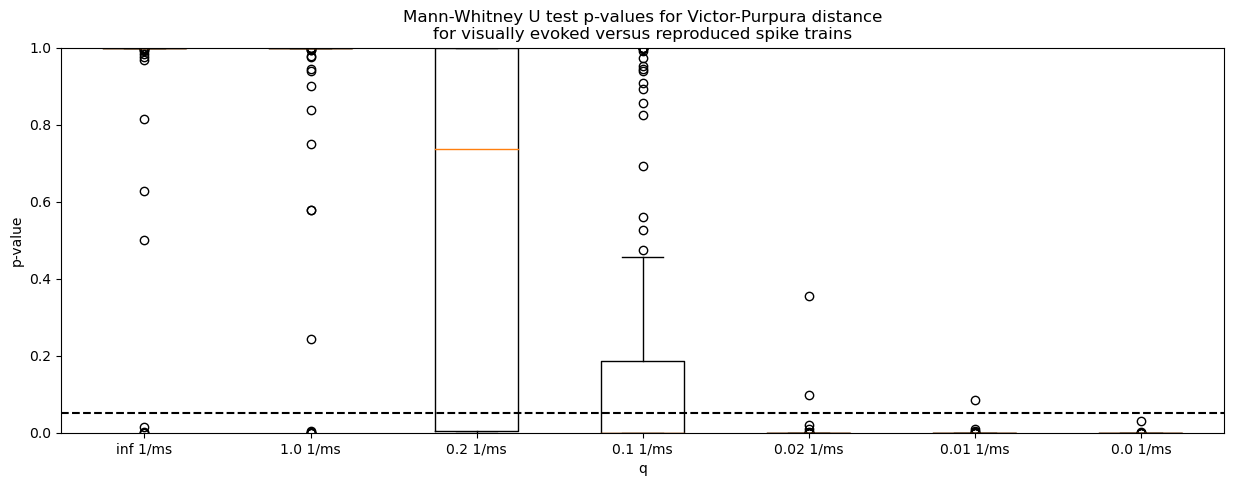

In [304]:
plt.figure(figsize=(15,5))

boxplot_data = []
for k,q in enumerate(q_list):
    boxplot_data.append(mannwhitney_p_values_together[1:,k])

plt.boxplot(boxplot_data, labels=q_list)

plt.axhline(alph, color='k', linestyle='--')
plt.xlabel("q")
plt.ylabel("p-value")
plt.ylim(0,1)
plt.title(f"Mann-Whitney U test p-values for Victor-Purpura distance\nfor visually evoked versus reproduced spike trains")
plt.show()

/Volumes/Lab/Development/anaconda3/envs/RETINA/lib/python3.9/site-packages/quantities/quantity.py:351: RuntimeWarning: divide by zero encountered in true_divide
  return np.true_divide(other, self)


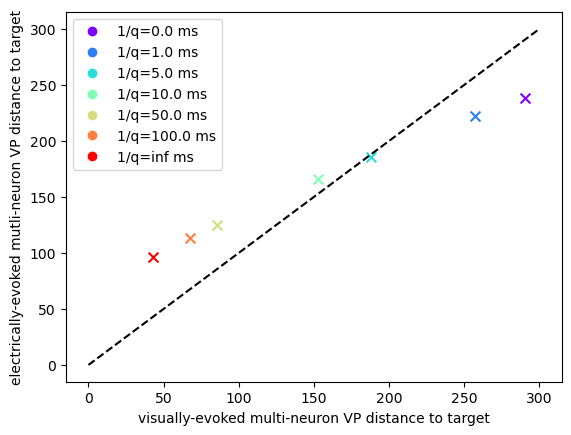

In [305]:
# vstim_vp_distances[cell,frame_no-5,q,trial]
# estim_espont_vp_distances[cell,frame_no-5,q,trial]

# Make a color vector from the rainbow colormap for each of the q values
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0, 1, len(q_list)))

# Make a shape vector for each of the 100 visual stimuli
shapes = ['o', 's', 'v', '^', '<', '>', 'D', 'p', 'P', 'X']

# Create the scatter plot
fig, ax = plt.subplots()
for i in range(len(colors)):
    # for j in range(100):
    #     ax.scatter(np.sum(vstim_vp_distances[:,j,i,:],axis=0), np.sum(estim_espont_vp_distances[:,j,i,:14],axis=0), color=colors[i], marker=shapes[j%10])
    # REMOVES EXLCUDED CELLS FROM THE TOTAL VP DISTANCE CALCULATION
    # for j in range(99):
    #     temp = estim_espont_vp_distances[:,j,i,:14]
    #     ax.scatter(np.sum(vstim_vp_distances[cells_to_include_mask,j,i,:],axis=0), np.sum(temp[cells_to_include_mask],axis=0), color=colors[i], marker=shapes[j%10])
    # ax.scatter(np.mean(np.sum(vstim_vp_distances[:,:,i,:],axis=0)), np.mean(np.sum(estim_espont_vp_distances[:,:,i,:14],axis=0)), color=colors[i], marker='x', s=50) # centroid
    # REMOVES EXLCUDED CELLS FROM THE TOTAL VP DISTANCE CALCULATION
    temp = estim_espont_vp_distances[:,:,i,:14]
    ax.scatter(np.mean(np.sum(vstim_vp_distances[cells_to_include_mask,:,i,:],axis=0)), np.mean(np.sum(temp[cells_to_include_mask],axis=0)), color=colors[i], marker='x', s=50) # centroid

# Set the labels and title
ax.set_xlabel('visually-evoked multi-neuron VP distance to target')
ax.set_ylabel('electrically-evoked mutli-neuron VP distance to target')

# Set the legend
legend_labels = [f"1/q={1/q}" for q in q_list]
legend_handles = [plt.Line2D([], [], color=colors[i], marker='o', linestyle='None') for i in range(len(colors))]
ax.legend(legend_handles, legend_labels)

# Make a x=y line
x = np.linspace(0, 300, 300)
ax.plot(x, x, color='k', linestyle='--')

# Show the plot
plt.show()